<a href="https://colab.research.google.com/github/yejxjj/2026-1_CV/blob/main/HW3_%EC%8B%A4%ED%97%98B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
from typing import Dict, List, Optional

plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 실험 하이퍼파라미터 설정

@dataclass
class LabConfig:
    # 데이터셋 관련
    n_samples: int = 1000           # make_moons 샘플 수
    moons_noise: float = 0.25       # 노이즈 수준
    test_ratio: float = 0.2

    # 네트워크 구조
    in_dim: int = 2                 # make_moons는 2차원 입력
    hidden1_dim: int = 256          # 첫 은닉층
    hidden2_dim: int = 128          # 두 번째 은닉층
    out_dim: int = 2                # 이진 분류

    # 학습 하이퍼파라미터
    batch_size: int = 64
    n_epochs: int = 300
    learning_rate: float = 0.01
    init_std: float = 0.01          # Dead Neuron 유도용 작은 초기값
    leaky_slope: float = 0.1        # LeakyReLU의 negative slope

    # 분석 임계값
    convergence_acc: float = 0.95   # 수렴 판정용 Val Acc 임계값
    dead_strict_eps: float = 1e-6   # 엄격한 Dead 판정 (모든 샘플에서 0)
    dead_loose_ratio: float = 0.95  # 완화된 Dead 판정 (95% 이상 샘플에서 0)
    grad_vanish_thr: float = 0.1  # Gradient vanishing 판정 임계값

    seed: int = 2025

CFG = LabConfig()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {DEVICE}")

# 시드 고정 (재현성 확보)
def lock_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

lock_seed(CFG.seed)

사용 디바이스: cuda


In [ ]:
# 활성화 함수 비교용 MLP 정의
# 구조: Linear(in→256) → Act → Linear(256→128) → Act → Linear(128→out)
# 활성화 함수와 초기화 방법을 인자로 받아 유연하게 교체 가능

def make_activation(name: str, slope: float = 0.1) -> nn.Module:

    n = name.lower()
    if n == "relu":
        return nn.ReLU()
    elif n == "leakyrelu":
        return nn.LeakyReLU(negative_slope=slope)
    elif n == "sigmoid":
        return nn.Sigmoid()
    else:
        raise ValueError(f"지원하지 않는 활성화 함수: {name}")


class DualHiddenNet(nn.Module):

    def __init__(self, cfg: LabConfig, activation_name: str, init_method: str = "normal_small"):
        super().__init__()
        self.activation_name = activation_name
        self.cfg = cfg

        # 레이어 정의
        self.fc_input = nn.Linear(cfg.in_dim, cfg.hidden1_dim)
        self.fc_middle = nn.Linear(cfg.hidden1_dim, cfg.hidden2_dim)
        self.fc_output = nn.Linear(cfg.hidden2_dim, cfg.out_dim)

        # 활성화 함수
        self.act1 = make_activation(activation_name, cfg.leaky_slope)
        self.act2 = make_activation(activation_name, cfg.leaky_slope)

        # 가중치 초기화
        self._init_weights(init_method)

    def _init_weights(self, method: str):

        for m in self.modules():
            if isinstance(m, nn.Linear):
                if method == "normal_small":
                    nn.init.normal_(m.weight, mean=0.0, std=self.cfg.init_std)
                elif method == "xavier":
                    nn.init.xavier_uniform_(m.weight)
                elif method == "he":
                    nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                else:
                    raise ValueError(f"지원하지 않는 초기화 방법: {method}")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, capture_acts: bool = False):

        captured = {}

        # 첫 은닉층
        z1 = self.fc_input(x)
        a1 = self.act1(z1)
        if capture_acts:
            captured[f"h1_{self.activation_name}"] = a1.detach().cpu().clone()

        # 두 번째 은닉층
        z2 = self.fc_middle(a1)
        a2 = self.act2(z2)
        if capture_acts:
            captured[f"h2_{self.activation_name}"] = a2.detach().cpu().clone()

        # 출력층 (logit 그대로 반환)
        out = self.fc_output(a2)

        if capture_acts:
            return out, captured
        return out

In [ ]:
# 데이터셋 준비 함수

def prepare_moons_data(cfg: LabConfig):

    X_raw, y_raw = make_moons(n_samples=cfg.n_samples,
                              noise=cfg.moons_noise,
                              random_state=cfg.seed)

    # 학습/테스트 분할 (stratify로 클래스 비율 유지)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_raw, y_raw,
        test_size=cfg.test_ratio,
        random_state=cfg.seed,
        stratify=y_raw
    )

    # 표준화 (평균 0, 표준편차 1로 정규화)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    # 텐서 변환
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    y_te_t = torch.tensor(y_te, dtype=torch.long)

    train_ds = TensorDataset(X_tr_t, y_tr_t)
    test_ds = TensorDataset(X_te_t, y_te_t)
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)

    return train_loader, test_loader, X_tr_t, y_tr_t, X_te_t, y_te_t

In [ ]:
# 학습 결과를 담을 dataclass와 학습 루프
# 학습 중간에 activation 분포, gradient norm 추이를 함께 기록

@dataclass
class TrainHistory:
    train_loss: List[float] = field(default_factory=list)
    val_loss: List[float] = field(default_factory=list)
    train_acc: List[float] = field(default_factory=list)
    val_acc: List[float] = field(default_factory=list)
    # 레이어별 epoch별 평균 gradient L2 norm
    grad_norms: Dict[str, List[float]] = field(default_factory=lambda: {
        "fc_input": [], "fc_middle": [], "fc_output": []
    })
    # 학습 단계별 activation 스냅샷 (초/중/후반)
    act_snapshots: Dict[str, Optional[Dict]] = field(default_factory=lambda: {
        "early": None, "mid": None, "late": None
    })
    convergence_epoch: Optional[int] = None


def fit_and_track(model: nn.Module, train_loader, test_loader,
                  criterion, optimizer, cfg: LabConfig) -> TrainHistory:
    hist = TrainHistory()
    # 어느 epoch에서 activation 스냅샷을 찍을지 결정
    snapshot_epochs = {
        0: "early",
        cfg.n_epochs // 2: "mid",
        cfg.n_epochs - 1: "late",
    }

    for epoch in range(cfg.n_epochs):
        # ===== 학습 단계 =====
        model.train()
        sum_loss = 0.0
        correct = 0
        total = 0

        # 레이어별 gradient norm 누적용
        layer_norm_acc = {"fc_input": 0.0, "fc_middle": 0.0, "fc_output": 0.0}
        n_batches = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()  # autograd 역전파

            # gradient L2 norm 기록 (weight만)
            with torch.no_grad():
                if model.fc_input.weight.grad is not None:
                    layer_norm_acc["fc_input"] += model.fc_input.weight.grad.norm().item()
                if model.fc_middle.weight.grad is not None:
                    layer_norm_acc["fc_middle"] += model.fc_middle.weight.grad.norm().item()
                if model.fc_output.weight.grad is not None:
                    layer_norm_acc["fc_output"] += model.fc_output.weight.grad.norm().item()

            optimizer.step()

            sum_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            n_batches += 1

        train_loss = sum_loss / total
        train_acc = correct / total
        hist.train_loss.append(train_loss)
        hist.train_acc.append(train_acc)

        # epoch별 평균 gradient norm 저장
        for k in layer_norm_acc:
            hist.grad_norms[k].append(layer_norm_acc[k] / max(n_batches, 1))

        # ===== 검증 단계 ======
        model.eval()
        sum_vloss = 0.0
        vcorrect = 0
        vtotal = 0
        snapshot_for_this_epoch = None

        with torch.no_grad():
            for i, (inputs, labels) in enumerate(test_loader):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                # 스냅샷 대상 epoch이면 첫 배치에서 activation 캡처
                if i == 0 and epoch in snapshot_epochs:
                    logits, captured = model(inputs, capture_acts=True)
                    snapshot_for_this_epoch = captured
                else:
                    logits = model(inputs)

                loss = criterion(logits, labels)
                sum_vloss += loss.item() * inputs.size(0)
                preds = torch.argmax(logits, dim=1)
                vcorrect += (preds == labels).sum().item()
                vtotal += labels.size(0)

        val_loss = sum_vloss / vtotal
        val_acc = vcorrect / vtotal
        hist.val_loss.append(val_loss)
        hist.val_acc.append(val_acc)

        # activation 스냅샷 저장
        if epoch in snapshot_epochs and snapshot_for_this_epoch is not None:
            hist.act_snapshots[snapshot_epochs[epoch]] = snapshot_for_this_epoch

        # 수렴 epoch 자동 판정 (val acc가 임계값 처음 돌파한 시점)
        if hist.convergence_epoch is None and val_acc >= cfg.convergence_acc:
            hist.convergence_epoch = epoch + 1

        # 진행 출력 (10% 단위)
        if (epoch + 1) % max(cfg.n_epochs // 10, 1) == 0 or epoch == cfg.n_epochs - 1:
            print(f"  Ep {epoch+1:3d}/{cfg.n_epochs} | "
                  f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
                  f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

    return hist

In [ ]:
# Dead Neuron 비율 계산
# 두 가지 기준으로 측정:
#   1. 모든 샘플에 대해 출력이 거의 0인 뉴런
#   2. 95% 이상의 샘플에서 출력이 0인 뉴런

@torch.no_grad()
def measure_dead_neurons(model: nn.Module, data_loader, cfg: LabConfig) -> Dict[str, Dict[str, float]]:
    """
    각 은닉층의 Dead Neuron 비율을 두 기준(strict/loose)으로 측정.
    추가로 Sigmoid의 경우 saturation 비율(0 또는 1 근처에 박힌 비율)도 계산.

    Returns:
        {layer_name: {"strict": ratio, "loose": ratio, "saturation": ratio}}
    """
    model.eval()
    act_buffer: Dict[str, List[torch.Tensor]] = {}

    for inputs, _ in data_loader:
        inputs = inputs.to(DEVICE)
        _, captured = model(inputs, capture_acts=True)
        for name, tensor in captured.items():
            act_buffer.setdefault(name, []).append(tensor.cpu())

    # 전체 샘플 분량을 합치기
    concat_acts = {name: torch.cat(tensors, dim=0)
                   for name, tensors in act_buffer.items()}

    results = {}
    for layer_name, acts in concat_acts.items():
        if acts.ndim < 2:
            continue
        n_neurons = acts.shape[1]
        if n_neurons == 0:
            continue

        layer_stat = {}

        if "sigmoid" in layer_name.lower():
            # Sigmoid: 모든 샘플에서 0 또는 1 근처에 박힌 뉴런 측정
            # 출력값이 항상 0.01 미만이거나 0.99 초과면 saturation
            sat_low = torch.all(acts < 0.01, dim=0)
            sat_high = torch.all(acts > 0.99, dim=0)
            sat_count = (sat_low | sat_high).sum().item()
            layer_stat["saturation"] = sat_count / n_neurons
            layer_stat["strict"] = 0.0  # Sigmoid는 Dead 개념이 다름
            layer_stat["loose"] = 0.0

        else:
            # ReLU 계열: Dead Neuron 정의
            eps = cfg.dead_strict_eps

            # 엄격: 모든 샘플에서 출력이 eps 이하
            strict_mask = torch.all(acts <= eps, dim=0)
            layer_stat["strict"] = strict_mask.sum().item() / n_neurons

            # 완화: 샘플의 95% 이상에서 출력이 eps 이하
            zero_ratio_per_neuron = (acts <= eps).float().mean(dim=0)
            loose_mask = zero_ratio_per_neuron >= cfg.dead_loose_ratio
            layer_stat["loose"] = loose_mask.sum().item() / n_neurons
            layer_stat["saturation"] = 0.0

        results[layer_name] = layer_stat

    return results

In [ ]:
# 시각화 함수 1: Loss/Accuracy 곡선 비교
# 세 활성화 함수를 같은 축에 겹쳐서 직관적 비교

def plot_curves_overlay(hist_dict: Dict[str, TrainHistory], cfg: LabConfig):
    """여러 활성화 함수의 Loss/Acc 곡선을 오버레이"""
    n_ep = cfg.n_epochs
    x_axis = range(1, n_ep + 1)

    palette = {"ReLU": "#2563EB", "LeakyReLU": "#10B981", "Sigmoid": "#DC2626"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, h in hist_dict.items():
        color = palette.get(name, "#666")
        axes[0].plot(x_axis, h.train_loss, color=color, linestyle="-",
                     label=f"{name} (train)", alpha=0.7)
        axes[0].plot(x_axis, h.val_loss, color=color, linestyle="--",
                     label=f"{name} (val)", alpha=0.9, linewidth=2)

        axes[1].plot(x_axis, [a*100 for a in h.train_acc], color=color,
                     linestyle="-", label=f"{name} (train)", alpha=0.7)
        axes[1].plot(x_axis, [a*100 for a in h.val_acc], color=color,
                     linestyle="--", label=f"{name} (val)", alpha=0.9, linewidth=2)

        # 수렴 시점 표시
        if h.convergence_epoch:
            axes[1].axvline(x=h.convergence_epoch, color=color,
                            linestyle=":", alpha=0.5)

    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curve Comparison")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].axhline(y=cfg.convergence_acc * 100, color="gray",
                    linestyle=":", label=f"{cfg.convergence_acc*100:.0f}% threshold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Accuracy Curve Comparison")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# 시각화 함수 2: Decision Boundary
# 모델이 학습한 분류 경계를 2D로 직접 보여줌

def plot_boundaries_grid(models: Dict[str, nn.Module], X_t: torch.Tensor, y_t: torch.Tensor):
    """여러 모델의 decision boundary를 격자로 비교"""
    X_np = X_t.cpu().numpy()
    y_np = y_t.cpu().numpy()

    # 격자 영역
    pad = 0.5
    x_lo, x_hi = X_np[:, 0].min() - pad, X_np[:, 0].max() + pad
    y_lo, y_hi = X_np[:, 1].min() - pad, X_np[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_lo, x_hi, 120),
                         np.linspace(y_lo, y_hi, 120))
    grid_pts = np.c_[xx.ravel(), yy.ravel()]
    grid_t = torch.tensor(grid_pts, dtype=torch.float32).to(DEVICE)

    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, models.items()):
        model.eval()
        with torch.no_grad():
            logits = model(grid_t)
            preds = torch.argmax(logits, dim=1).cpu().numpy().reshape(xx.shape)

        ax.contourf(xx, yy, preds, alpha=0.4, cmap=plt.cm.RdYlBu)
        ax.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=18,
                   edgecolor='k', linewidths=0.5, cmap=plt.cm.RdYlBu)
        ax.set_title(f"{name}\nDecision Boundary")
        ax.set_xlabel("Feature 1 (scaled)")
        ax.set_ylabel("Feature 2 (scaled)")

    plt.tight_layout()
    plt.show()

In [ ]:
# 시각화 함수 3: 학습 단계별 activation 분포
# 초/중/후반 3시점에서 각 hidden layer의 activation 히스토그램

def plot_activation_evolution(hist: TrainHistory, activation_name: str):
    stages = ["early", "mid", "late"]

    first_valid = next((hist.act_snapshots[s] for s in stages
                       if hist.act_snapshots[s] is not None), None)
    if first_valid is None:
        print(f"[{activation_name}] No activation snapshot available")
        return

    layer_names = list(first_valid.keys())
    n_layers = len(layer_names)

    fig, axes = plt.subplots(len(stages), n_layers,
                              figsize=(5 * n_layers, 3.5 * len(stages)),
                              squeeze=False)
    fig.suptitle(f"{activation_name} - Activation Distribution Across Training Stages",
                 fontsize=15, y=1.01)

    for r, stage in enumerate(stages):
        snap = hist.act_snapshots[stage]
        if snap is None:
            for c in range(n_layers):
                axes[r, c].text(0.5, 0.5, "No data",
                                ha="center", va="center", transform=axes[r, c].transAxes)
            continue

        for c, lname in enumerate(layer_names):
            data = snap[lname].flatten().numpy()
            zero_pct = (np.abs(data) < 1e-6).mean() * 100

            ax = axes[r, c]
            sns.histplot(data, bins=40, ax=ax, color="steelblue",
                         alpha=0.7, edgecolor="white")
            ax.set_title(f"{stage} - {lname.split('_')[0]}\n"
                         f"(zero ratio: {zero_pct:.1f}%)", fontsize=10)
            ax.set_xlabel("Activation Value", fontsize=9)
            ax.set_ylabel("Frequency", fontsize=9)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# 시각화 함수 4: Sigmoid 전용 — vanishing gradient 분석
# Sigmoid의 도함수는 σ'(z) = a(1-a). a가 0 또는 1에 가까우면 도함수가 0에 수렴.
# 이게 vanishing gradient의 원인.

def plot_sigmoid_gradient_analysis(hist: TrainHistory, cfg: LabConfig):
    stages = ["early", "mid", "late"]

    first_valid = next((hist.act_snapshots[s] for s in stages
                       if hist.act_snapshots[s] is not None), None)
    if first_valid is None:
        print("No snapshot available")
        return

    layer_names = list(first_valid.keys())
    n_layers = len(layer_names)

    fig, axes = plt.subplots(len(stages), n_layers,
                              figsize=(5 * n_layers, 3.5 * len(stages)),
                              squeeze=False)
    fig.suptitle("Sigmoid Derivative Distribution: sigma'(z) = a(1-a)",
                 fontsize=15, y=1.01)

    vanish_records = []

    for r, stage in enumerate(stages):
        snap = hist.act_snapshots[stage]
        if snap is None:
            continue

        for c, lname in enumerate(layer_names):
            a = snap[lname].flatten()
            grad = a * (1 - a)
            vanish_pct = (grad < 0.01).float().mean().item() * 100

            ax = axes[r, c]
            sns.histplot(grad.numpy(), bins=40, ax=ax,
                         color="#7C3AED", alpha=0.7, edgecolor="white")
            ax.set_title(f"{stage} - {lname.split('_')[0]}\n"
                         f"(ratio of sigma' < 0.01: {vanish_pct:.1f}%)", fontsize=10)
            ax.set_xlabel("sigma'(z)", fontsize=9)
            ax.set_ylabel("Frequency", fontsize=9)
            ax.set_xlim(0, 0.26)
            ax.grid(True, alpha=0.3)

            vanish_records.append({
                "Stage": stage,
                "Layer": lname.split('_')[0],
                "sigma' < 0.01 (%)": round(vanish_pct, 1)
            })

    plt.tight_layout()
    plt.show()

    df_vanish = pd.DataFrame(vanish_records).pivot(
        index="Layer", columns="Stage", values="sigma' < 0.01 (%)"
    )
    print("\n[Sigmoid derivative vanishing ratio (%) by training stage]")
    print(df_vanish)

In [ ]:
# 시각화 함수 5: Dead Neuron 비율 히트맵
# 활성화 함수 × 레이어 매트릭스로 한눈에 비교
# 두 가지 기준(strict, loose) 모두 보여줌

def plot_dead_neuron_heatmaps(dead_stats: Dict[str, Dict[str, Dict[str, float]]]):
    records_strict = []
    records_loose = []
    records_sat = []

    for act_name, layers in dead_stats.items():
        for lname, stats in layers.items():
            short_layer = lname.split('_')[0]
            if "sigmoid" in lname.lower():
                records_sat.append({
                    "Activation": act_name,
                    "Layer": short_layer,
                    "Ratio (%)": stats.get("saturation", 0) * 100
                })
            else:
                records_strict.append({
                    "Activation": act_name,
                    "Layer": short_layer,
                    "Ratio (%)": stats.get("strict", 0) * 100
                })
                records_loose.append({
                    "Activation": act_name,
                    "Layer": short_layer,
                    "Ratio (%)": stats.get("loose", 0) * 100
                })

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1) Strict Dead ReLU
    if records_strict:
        df_s = pd.DataFrame(records_strict).pivot(
            index="Layer", columns="Activation", values="Ratio (%)"
        )
        sns.heatmap(df_s, annot=True, fmt=".1f", cmap="YlOrRd",
                    linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Ratio (%)'},
                    vmin=0, vmax=100)
        axes[0].set_title("Dead Neuron Ratio (Strict)\nAll samples output near 0")
    else:
        axes[0].set_visible(False)

    # 2) Loose Dead ReLU
    if records_loose:
        df_l = pd.DataFrame(records_loose).pivot(
            index="Layer", columns="Activation", values="Ratio (%)"
        )
        sns.heatmap(df_l, annot=True, fmt=".1f", cmap="YlOrRd",
                    linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Ratio (%)'},
                    vmin=0, vmax=100)
        axes[1].set_title("Dead Neuron Ratio (Loose)\n>=95% samples output near 0")
    else:
        axes[1].set_visible(False)

    # 3) Sigmoid Saturation
    if records_sat:
        df_sat = pd.DataFrame(records_sat).pivot(
            index="Layer", columns="Activation", values="Ratio (%)"
        )
        sns.heatmap(df_sat, annot=True, fmt=".1f", cmap="Purples",
                    linewidths=0.5, ax=axes[2], cbar_kws={'label': 'Ratio (%)'},
                    vmin=0, vmax=100)
        axes[2].set_title("Sigmoid Saturation Ratio\nNeurons stuck near 0 or 1")
    else:
        axes[2].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
# 시각화 함수 6: Layer별 Gradient 흐름
# 각 활성화 함수에 대해 epoch별 레이어별 gradient norm 추이를 히트맵으로

def plot_gradient_flow(hist_dict: Dict[str, TrainHistory], cfg: LabConfig):
    """세 활성화 함수의 gradient 흐름을 히트맵 + 라인 그래프로 비교"""
    n_models = len(hist_dict)

    # ===== 히트맵 (정규화된 gradient strength) =====
    fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 3.5))
    if n_models == 1:
        axes = [axes]

    for ax, (name, hist) in zip(axes, hist_dict.items()):
        df = pd.DataFrame(hist.grad_norms).T  # rows: layer, cols: epoch
        # log(1+x) 변환으로 dynamic range 압축
        df_log = np.log1p(df.replace(0, np.nan))
        # 행별로 0~1 정규화 (레이어별 상대적 강도)
        df_norm = df_log.div(df_log.max(axis=1), axis=0)

        sns.heatmap(df_norm, cmap="YlGnBu", vmin=0, vmax=1,
                    cbar_kws={'label': 'Gradient Strength (normalized)'},
                    ax=ax)
        ax.set_title(f"{name}\nLayer-wise Gradient Strength")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Layer")

    plt.tight_layout()
    plt.show()


    # ===== Gradient norm 추이 라인 그래프 (로그 스케일) =====
    fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 4),
                              sharey=True)
    if n_models == 1:
        axes = [axes]

    layer_colors = {"fc_input": "#0D9488", "fc_middle": "#F59E0B", "fc_output": "#7C3AED"}

    for ax, (name, hist) in zip(axes, hist_dict.items()):
        x_axis = range(1, len(hist.grad_norms["fc_input"]) + 1)
        for lname, vals in hist.grad_norms.items():
            ax.plot(x_axis, vals, label=lname, color=layer_colors[lname], linewidth=1.5)
        ax.set_yscale("log")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Mean Gradient L2 Norm (log)")
        ax.set_title(f"{name}\nGradient Norm Trajectory")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# 메인 실험 실행
# 세 활성화 함수에 대해 동일 조건으로 학습 후 결과 비교

print("="*70)
print("실험 B 메인: ReLU vs LeakyReLU vs Sigmoid")
print("="*70)

# 데이터 준비 (한 번만)
train_loader, test_loader, X_tr_t, y_tr_t, X_te_t, y_te_t = prepare_moons_data(CFG)
print(f"학습 샘플: {len(X_tr_t)}, 테스트 샘플: {len(X_te_t)}")

# 비교할 활성화 함수 목록
activations_to_test = ["ReLU", "LeakyReLU", "Sigmoid"]

# 결과 저장
histories: Dict[str, TrainHistory] = {}
trained_models: Dict[str, nn.Module] = {}
dead_stats: Dict[str, Dict[str, Dict[str, float]]] = {}

criterion = nn.CrossEntropyLoss()

for act_name in activations_to_test:
    print(f"\n--- {act_name} 학습 시작 ---")
    lock_seed(CFG.seed)  # 매 실험마다 시드 재고정 (공정 비교)

    model = DualHiddenNet(CFG, activation_name=act_name,
                          init_method="normal_small").to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=CFG.learning_rate)

    hist = fit_and_track(model, train_loader, test_loader,
                         criterion, optimizer, CFG)

    histories[act_name] = hist
    trained_models[act_name] = model
    dead_stats[act_name] = measure_dead_neurons(model, train_loader, CFG)

    if hist.convergence_epoch:
        print(f"  [수렴] {hist.convergence_epoch} epoch에서 "
              f"{CFG.convergence_acc*100:.0f}% 돌파")
    else:
        print(f"  [미수렴] {CFG.n_epochs} epoch 내 {CFG.convergence_acc*100:.0f}% 미달")

실험 B 메인: ReLU vs LeakyReLU vs Sigmoid
학습 샘플: 800, 테스트 샘플: 200

--- ReLU 학습 시작 ---
  Ep  30/300 | Train Loss 0.1415 Acc 0.9413 | Val Loss 0.1311 Acc 0.9450
  Ep  60/300 | Train Loss 0.1254 Acc 0.9475 | Val Loss 0.1229 Acc 0.9550
  Ep  90/300 | Train Loss 0.1237 Acc 0.9475 | Val Loss 0.1281 Acc 0.9650
  Ep 120/300 | Train Loss 0.1288 Acc 0.9475 | Val Loss 0.1507 Acc 0.9500
  Ep 150/300 | Train Loss 0.1160 Acc 0.9525 | Val Loss 0.1549 Acc 0.9500
  Ep 180/300 | Train Loss 0.1266 Acc 0.9425 | Val Loss 0.1270 Acc 0.9650
  Ep 210/300 | Train Loss 0.1071 Acc 0.9550 | Val Loss 0.1523 Acc 0.9550
  Ep 240/300 | Train Loss 0.1048 Acc 0.9525 | Val Loss 0.1613 Acc 0.9550
  Ep 270/300 | Train Loss 0.1005 Acc 0.9587 | Val Loss 0.1611 Acc 0.9550
  Ep 300/300 | Train Loss 0.1024 Acc 0.9550 | Val Loss 0.1658 Acc 0.9500
  [수렴] 5 epoch에서 95% 돌파

--- LeakyReLU 학습 시작 ---
  Ep  30/300 | Train Loss 0.1353 Acc 0.9425 | Val Loss 0.1249 Acc 0.9550
  Ep  60/300 | Train Loss 0.1331 Acc 0.9475 | Val Loss 0.1266 Acc 

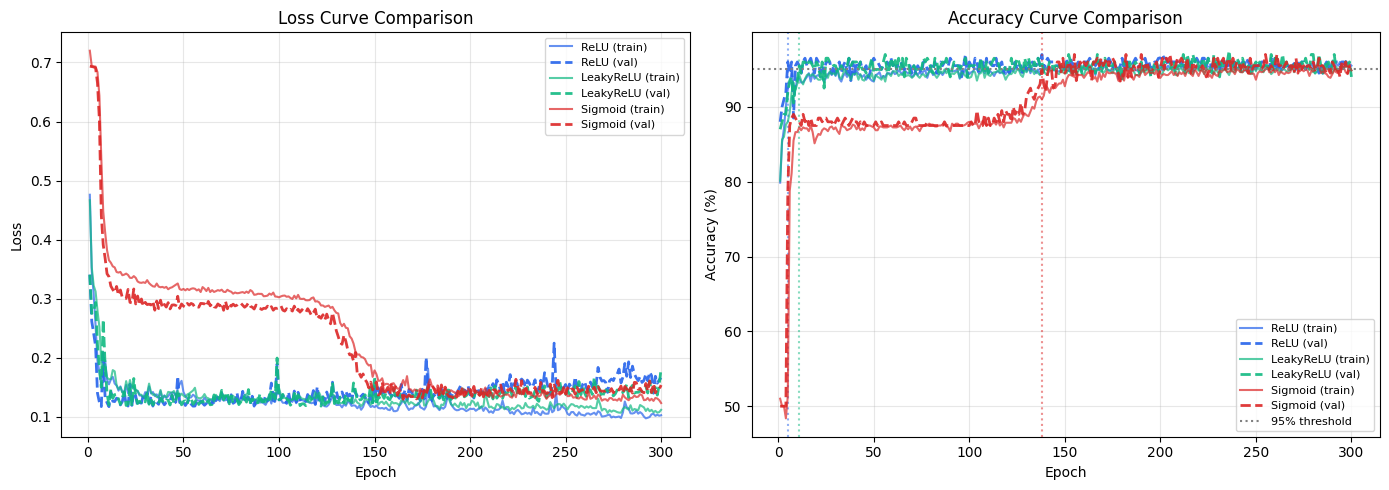

In [ ]:
# 시각화 1: Loss/Accuracy 오버레이 (전체 비교)
plot_curves_overlay(histories, CFG)

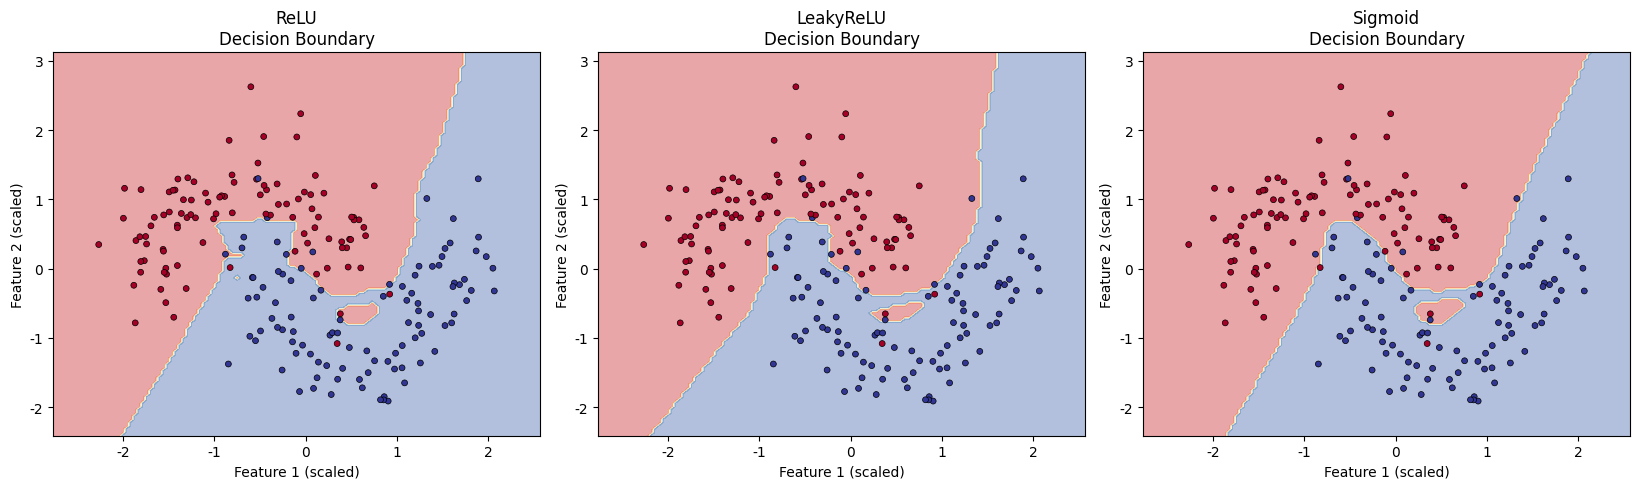

In [ ]:
# 시각화 2: Decision Boundary 비교
plot_boundaries_grid(trained_models, X_te_t, y_te_t)

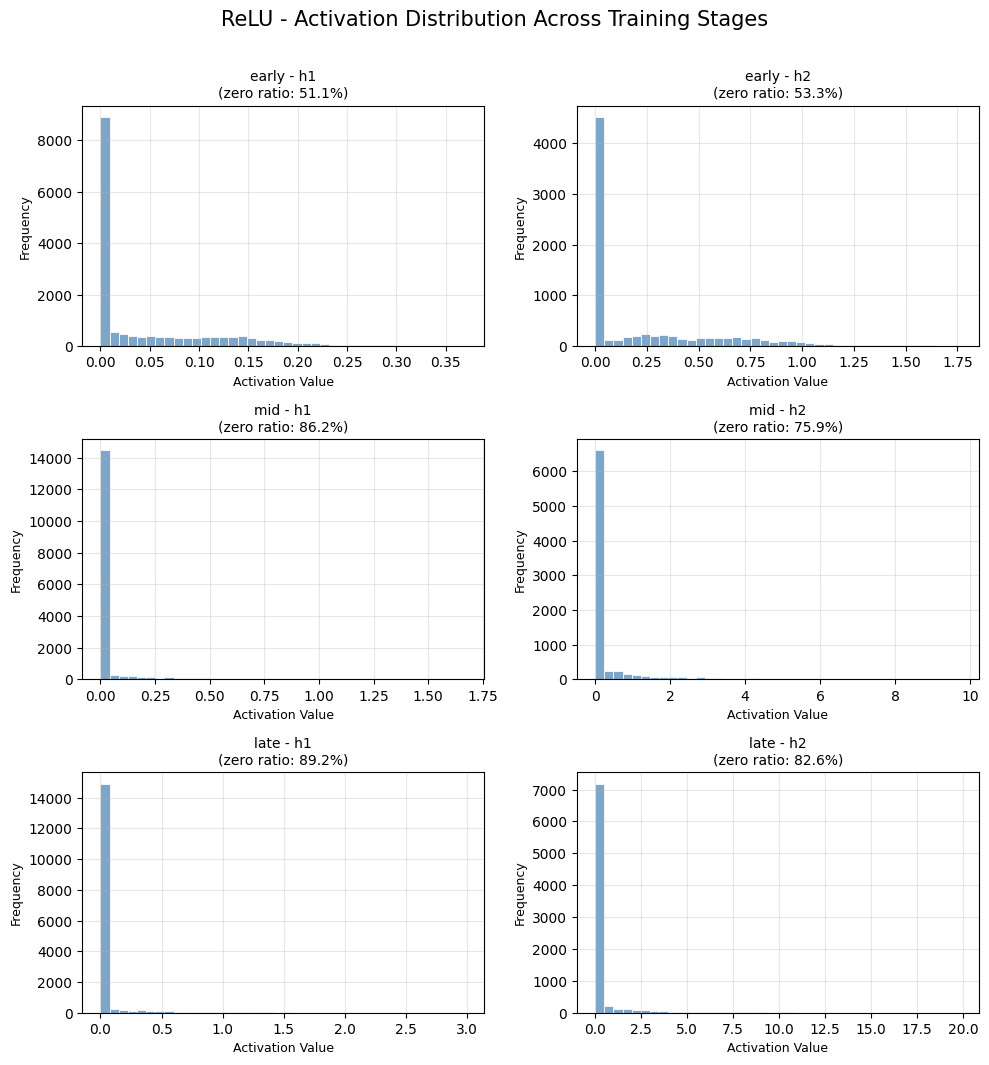

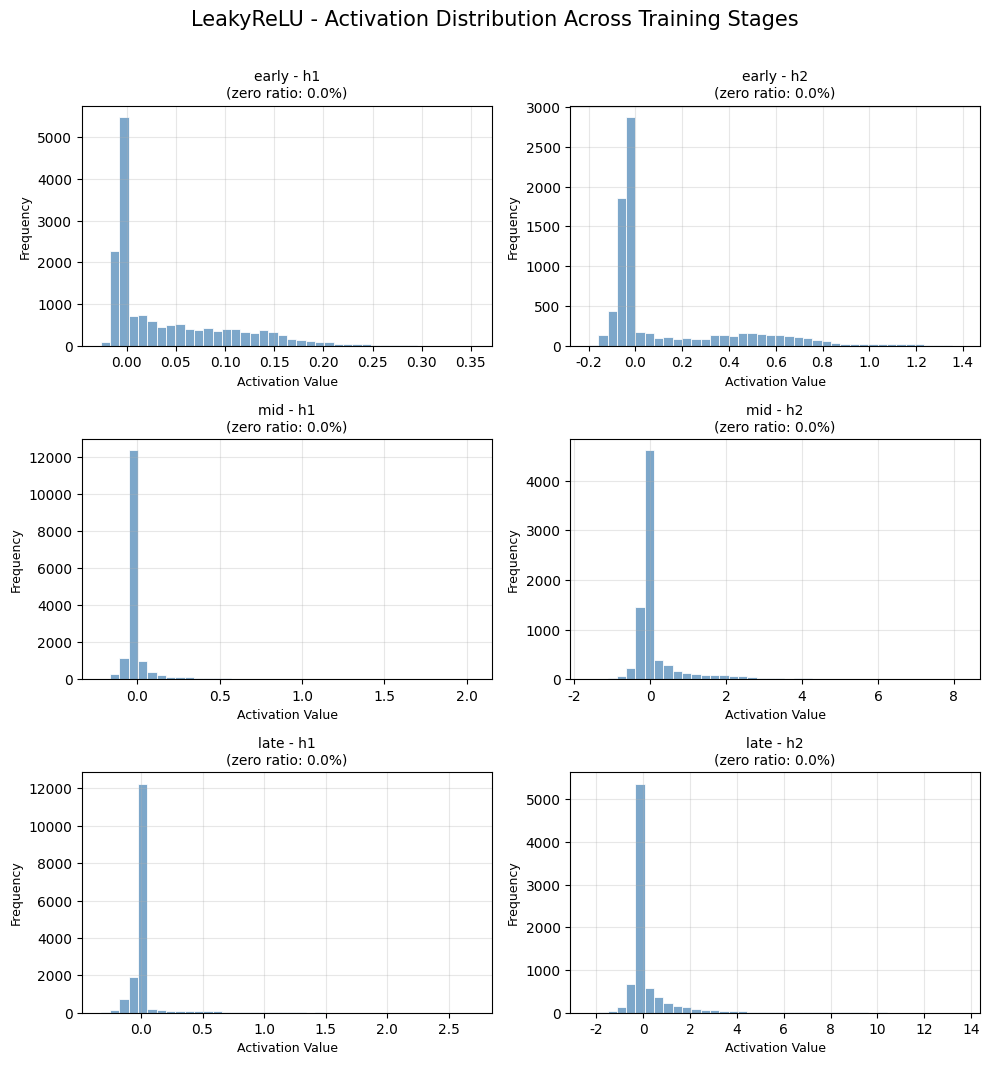

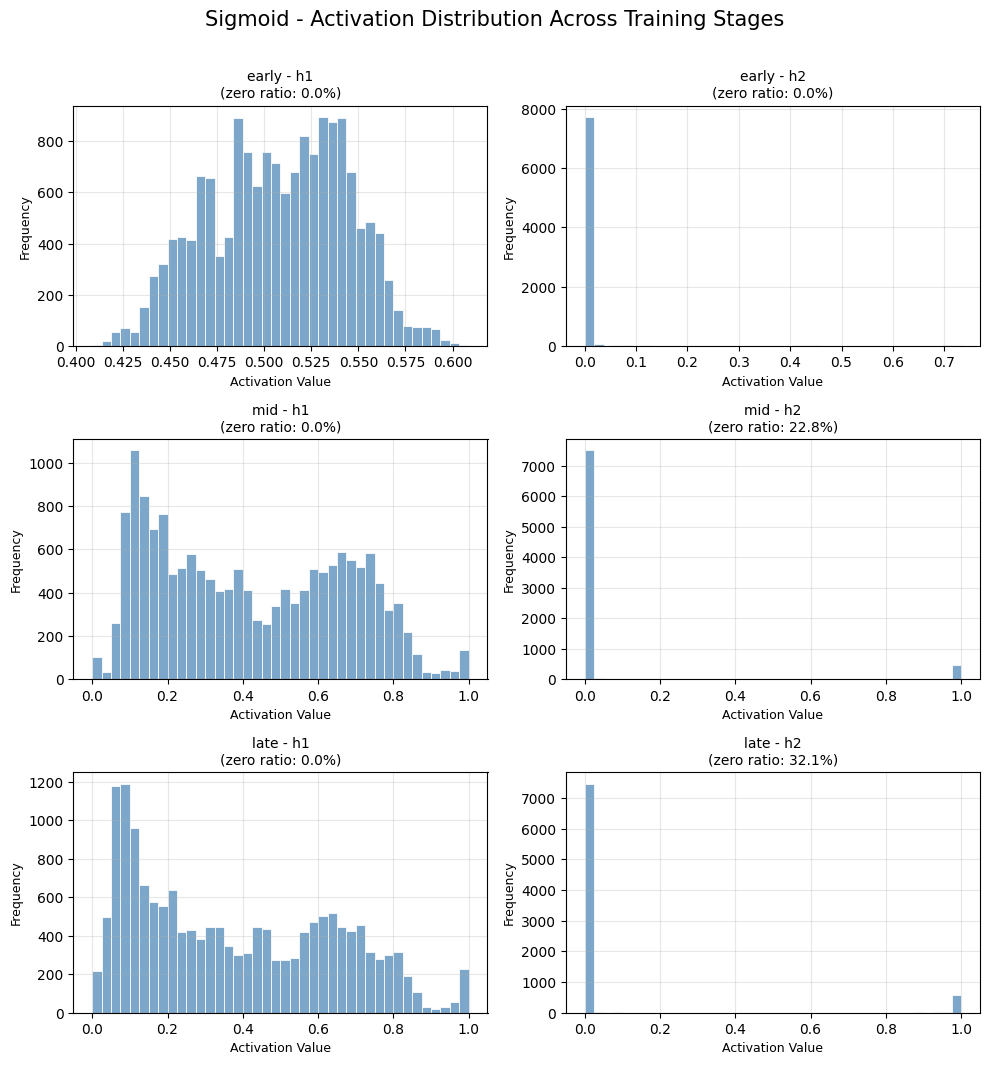

In [ ]:
# 시각화 3: 학습 단계별 activation 분포 변화 (활성화 함수별)
for act_name in activations_to_test:
    plot_activation_evolution(histories[act_name], act_name)

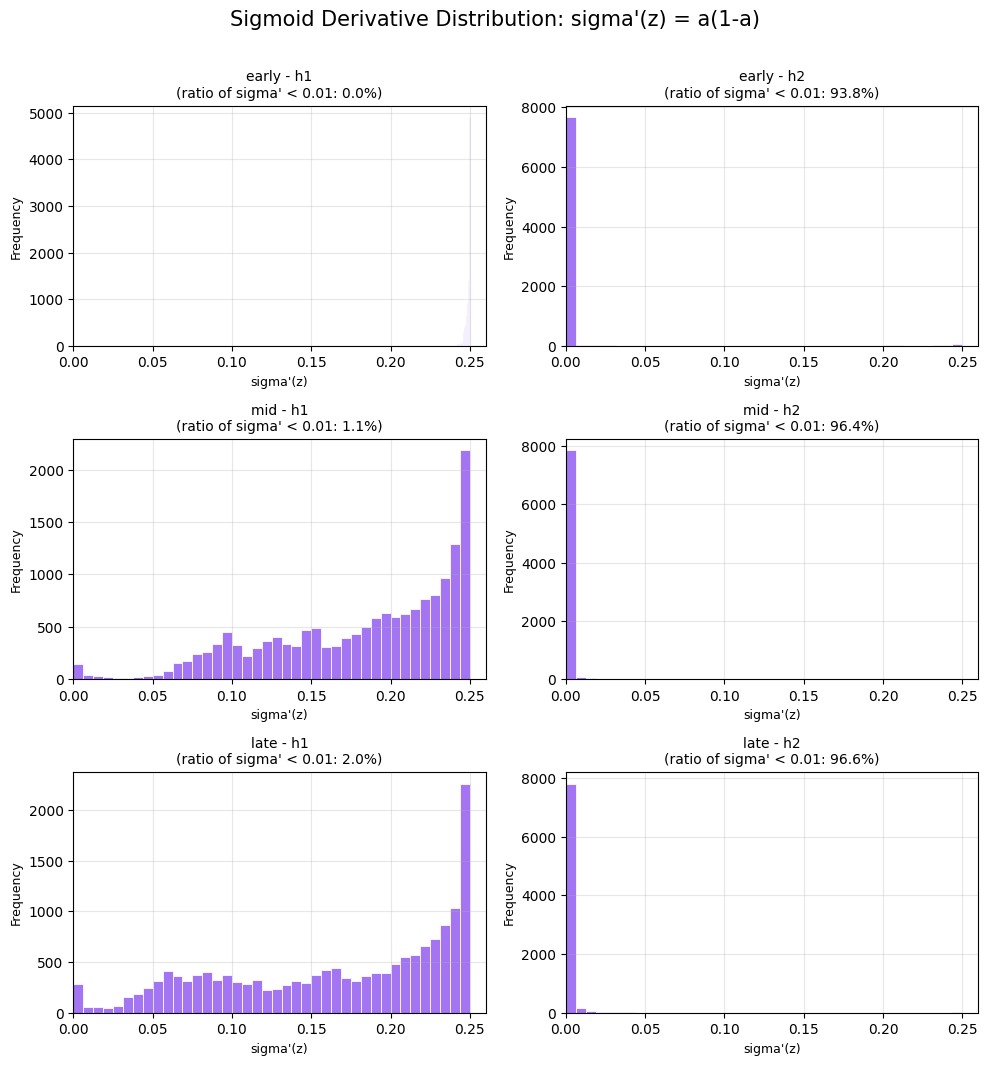


[Sigmoid derivative vanishing ratio (%) by training stage]
Stage  early  late   mid
Layer                   
h1       0.0   2.0   1.1
h2      93.8  96.6  96.4


In [ ]:
# 시각화 4: Sigmoid 전용 도함수 분포 분석
plot_sigmoid_gradient_analysis(histories["Sigmoid"], CFG)

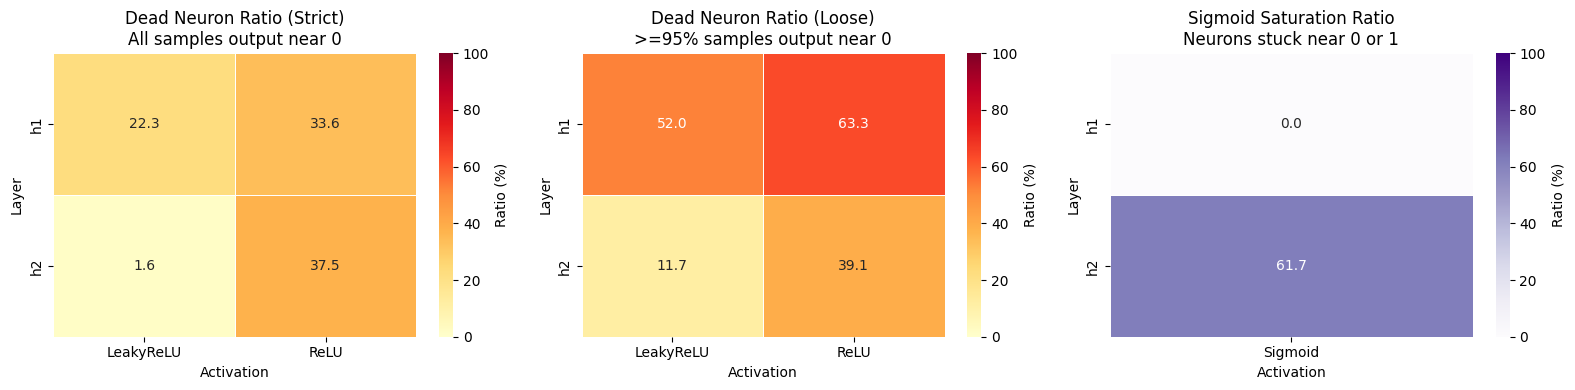

In [ ]:
# 시각화 5: Dead Neuron 비율 히트맵 (엄격/완화/Sigmoid saturation)
plot_dead_neuron_heatmaps(dead_stats)

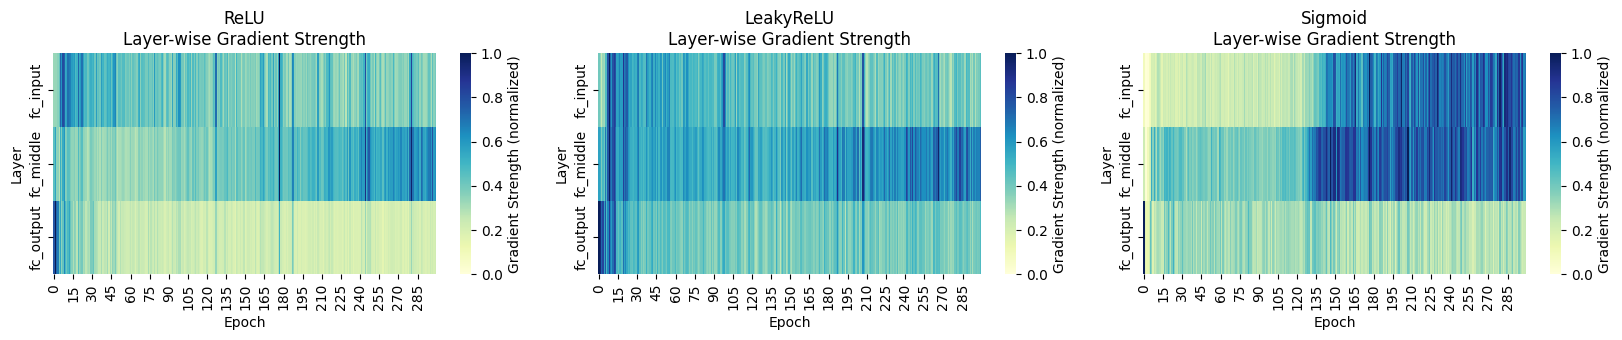

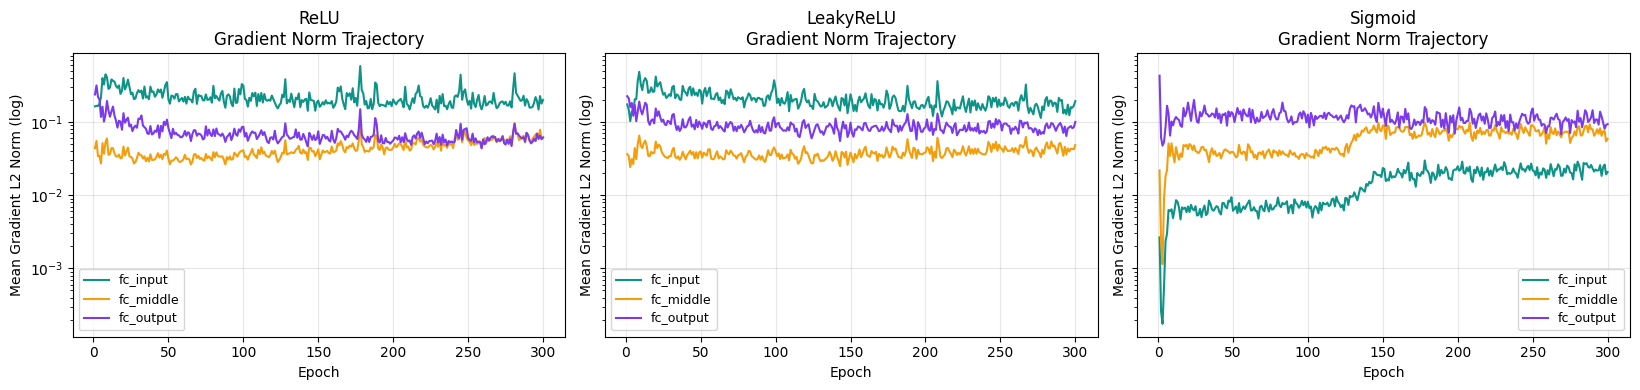

In [ ]:
# 시각화 6: Layer별 Gradient 흐름 분석
plot_gradient_flow(histories, CFG)

In [ ]:
# 정량 비교표 출력
# 과제 요구사항 표 양식: 활성화 함수 / Dead ReLU 비율 / 최종 정확도 / 수렴 속도

print("\n" + "="*80)
print(" "*25 + "실험 B 정량 비교 요약")
print("="*80)

summary_rows = []
for act_name in activations_to_test:
    hist = histories[act_name]
    final_acc = hist.val_acc[-1] * 100
    conv = hist.convergence_epoch if hist.convergence_epoch else f">{CFG.n_epochs}"

    # Dead 비율 계산 (h1, h2 평균)
    dead = dead_stats[act_name]
    if "sigmoid" in act_name.lower():
        # Sigmoid는 saturation 비율로 대체
        sat_vals = [v["saturation"] for v in dead.values()]
        dead_str = f"sat {np.mean(sat_vals)*100:.1f}" if sat_vals else "N/A"
    else:
        strict_vals = [v["strict"] for v in dead.values()]
        loose_vals = [v["loose"] for v in dead.values()]
        dead_str = (f"엄격 {np.mean(strict_vals)*100:.1f} / "
                    f"완화 {np.mean(loose_vals)*100:.1f}")

    summary_rows.append({
        "활성화 함수": act_name,
        "Dead 비율 (%)": dead_str,
        "최종 정확도 (%)": f"{final_acc:.2f}",
        "수렴 속도(epoch)": str(conv)
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
print("="*80)



                         실험 B 정량 비교 요약
   활성화 함수       Dead 비율 (%) 최종 정확도 (%) 수렴 속도(epoch)
     ReLU 엄격 35.5 / 완화 51.2      95.00            5
LeakyReLU 엄격 11.9 / 완화 31.8      94.00           11
  Sigmoid          sat 30.9      95.50          138



Ablation: Sigmoid + Xavier Initialization
  Ep  30/300 | Train Loss 0.3263 Acc 0.8600 | Val Loss 0.2805 Acc 0.8800
  Ep  60/300 | Train Loss 0.2663 Acc 0.8862 | Val Loss 0.2205 Acc 0.9250
  Ep  90/300 | Train Loss 0.1434 Acc 0.9425 | Val Loss 0.1362 Acc 0.9500
  Ep 120/300 | Train Loss 0.1477 Acc 0.9463 | Val Loss 0.1363 Acc 0.9500
  Ep 150/300 | Train Loss 0.1402 Acc 0.9425 | Val Loss 0.1392 Acc 0.9400
  Ep 180/300 | Train Loss 0.1409 Acc 0.9450 | Val Loss 0.1290 Acc 0.9500
  Ep 210/300 | Train Loss 0.1283 Acc 0.9450 | Val Loss 0.1481 Acc 0.9500
  Ep 240/300 | Train Loss 0.1283 Acc 0.9463 | Val Loss 0.1325 Acc 0.9550
  Ep 270/300 | Train Loss 0.1255 Acc 0.9425 | Val Loss 0.1369 Acc 0.9550
  Ep 300/300 | Train Loss 0.1211 Acc 0.9463 | Val Loss 0.1370 Acc 0.9550


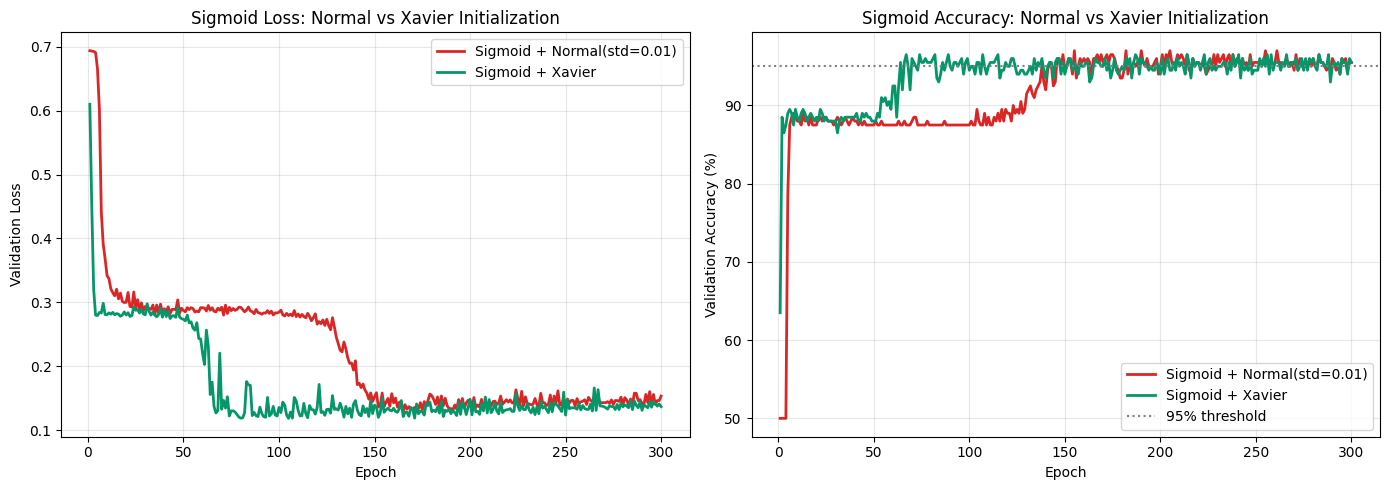


[Initialization Comparison]
  Normal(std=0.01): Final Acc 95.50%, Convergence 138
  Xavier          : Final Acc 95.50%, Convergence 64


In [ ]:
# Ablation: Sigmoid의 vanishing gradient 완화 방안 검증
# Xavier(Glorot) 초기화는 saturating 활성화 함수에 적합한 방법
# Default 작은 std 초기화와 비교하여 학습 성능 차이 확인

print("\n" + "="*70)
print("Ablation: Sigmoid + Xavier Initialization")
print("="*70)

lock_seed(CFG.seed)
model_xavier = DualHiddenNet(CFG, activation_name="Sigmoid",
                              init_method="xavier").to(DEVICE)
optimizer_xavier = optim.Adam(model_xavier.parameters(), lr=CFG.learning_rate)

hist_xavier = fit_and_track(model_xavier, train_loader, test_loader,
                             criterion, optimizer_xavier, CFG)

# 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_axis = range(1, CFG.n_epochs + 1)

# Sigmoid 두 가지 초기화 비교
axes[0].plot(x_axis, histories["Sigmoid"].val_loss,
             color="#DC2626", label="Sigmoid + Normal(std=0.01)", linewidth=2)
axes[0].plot(x_axis, hist_xavier.val_loss,
             color="#059669", label="Sigmoid + Xavier", linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Loss")
axes[0].set_title("Sigmoid Loss: Normal vs Xavier Initialization")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x_axis, [a*100 for a in histories["Sigmoid"].val_acc],
             color="#DC2626", label="Sigmoid + Normal(std=0.01)", linewidth=2)
axes[1].plot(x_axis, [a*100 for a in hist_xavier.val_acc],
             color="#059669", label="Sigmoid + Xavier", linewidth=2)
axes[1].axhline(y=CFG.convergence_acc * 100, color="gray", linestyle=":",
                label=f"{CFG.convergence_acc*100:.0f}% threshold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy (%)")
axes[1].set_title("Sigmoid Accuracy: Normal vs Xavier Initialization")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 정량 비교
orig_conv = histories["Sigmoid"].convergence_epoch
xav_conv = hist_xavier.convergence_epoch
print(f"\n[Initialization Comparison]")
print(f"  Normal(std=0.01): Final Acc {histories['Sigmoid'].val_acc[-1]*100:.2f}%, "
      f"Convergence {orig_conv if orig_conv else 'Not converged'}")
print(f"  Xavier          : Final Acc {hist_xavier.val_acc[-1]*100:.2f}%, "
      f"Convergence {xav_conv if xav_conv else 'Not converged'}")